# SCALE: Self-Calibrated Anomaly Detection with FlashBackGraph

This notebook shows how to use a **FlashBackGraph foundation model** to flag
anomalous (likely erroneous) immune-receptor sequences with **SCALE**, the
self-calibrated FlashBack anomaly score.

**The idea.** A sequence is anomalous if the repertoire model assigns it a very
low generation probability. A natural score is therefore `-log pgen`. The
problem: `-log pgen` grows with sequence length, so a raw cutoff just flags long
sequences. SCALE removes that length dependence by calibrating against the
foundation's own simulated output, giving a length-invariant score.

**What you need**

- The published **foundation FlashBack graph** (`flashback_foundation.lzg`),
  available as a downloadable asset on the LZGraphs GitHub release. Download it
  and point `FOUNDATION` below at it.
- `numpy`, `matplotlib`, and (for the ROC curve) `scikit-learn`.


In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

from LZGraphs import FlashBackGraph, ScaleCalibration

plt.rcParams["figure.figsize"] = (7, 4)
plt.rcParams["axes.grid"] = True
rng = np.random.default_rng(0)

## 1. Load the foundation graph

The foundation graph is a large FlashBackGraph built from a broad pool of
CDR3 sequences. It loads in about a second and serves as the reference model:
typical sequences are probable under it, errors are not.

In [2]:
FOUNDATION = "flashback_foundation.lzg"   # path to the downloaded release asset
g = FlashBackGraph.load(FOUNDATION)
print(f"foundation: {g.n_nodes:,} nodes, {g.n_edges:,} edges")

foundation: 71,181 nodes, 11,714,847 edges


## 2. Why raw -log Pgen needs calibration

Simulate a large reference set straight from the foundation (these are, by
construction, *typical* sequences), score their `-log Pgen`, and plot it against
sequence length. The upward trend is the length dependence we need to remove.
We simulate 1,000,000 sequences and plot a readable subsample.

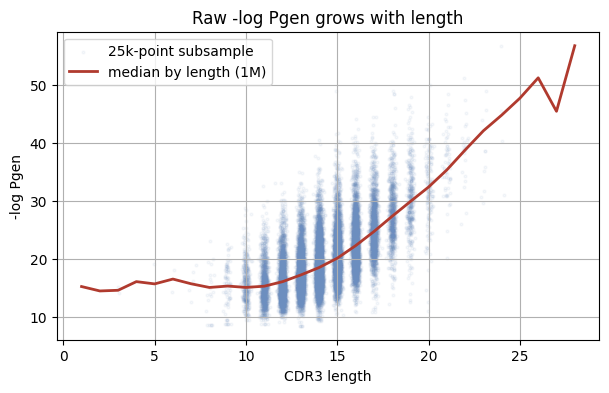

In [3]:
ref = g.simulate(1_000_000, seed=1)
ref_seqs = list(ref.sequences)
ref_neglp = -np.asarray(ref.log_probs, dtype=float)
ref_len = np.array([len(s) for s in ref_seqs])

# median -log Pgen per length, computed on the full 1M reference
Ls = np.arange(ref_len.min(), ref_len.max() + 1)
med = [np.median(ref_neglp[ref_len == L]) if (ref_len == L).any() else np.nan for L in Ls]

# scatter a readable subsample of the 1M points
samp = rng.choice(len(ref_len), size=25_000, replace=False)
plt.scatter(ref_len[samp] + rng.normal(0, 0.1, samp.size), ref_neglp[samp],
            s=4, alpha=0.06, color="#6c8ebf", label="25k-point subsample")
plt.plot(Ls, med, color="#b03a2e", lw=2, label="median by length (1M)")
plt.xlabel("CDR3 length"); plt.ylabel("-log Pgen")
plt.title("Raw -log Pgen grows with length")
plt.legend(); plt.show()

## 3. Self-calibrate: build the SCALE cache

`calibrate_scale` does exactly the simulation above and records, **per length**,
the median and IQR of `-log Pgen`. That table is the calibration cache. Save it
to JSON so you never have to re-simulate.

ScaleCalibration(lengths=20, global_median=19.433, global_iqr=6.933, n_sim=1000000)


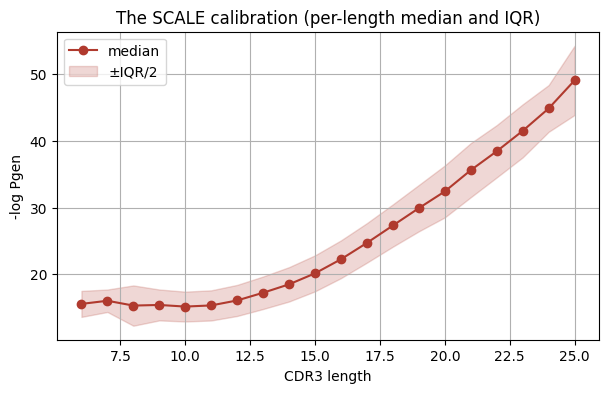

In [4]:
calibration = g.calibrate_scale(n_sim=1_000_000, seed=2)
calibration.save("scale_calibration.json")
print(calibration)

lengths = sorted(calibration.median_by_length)
meds = [calibration.median_by_length[L] for L in lengths]
iqrs = [calibration.iqr_by_length[L] for L in lengths]

fig, ax = plt.subplots()
ax.plot(lengths, meds, "o-", color="#b03a2e", label="median")
ax.fill_between(lengths,
                np.array(meds) - np.array(iqrs) / 2,
                np.array(meds) + np.array(iqrs) / 2,
                alpha=0.2, color="#b03a2e", label="±IQR/2")
ax.set_xlabel("CDR3 length"); ax.set_ylabel("-log Pgen")
ax.set_title("The SCALE calibration (per-length median and IQR)")
ax.legend(); plt.show()

## 4. The SCALE score is length-invariant

`scale_score(s) = (-log Pgen(s) - median[len(s)]) / IQR[len(s)]`. Scoring a
sample of the reference now gives a distribution centred near zero with no
length trend: the calibration has done its job.

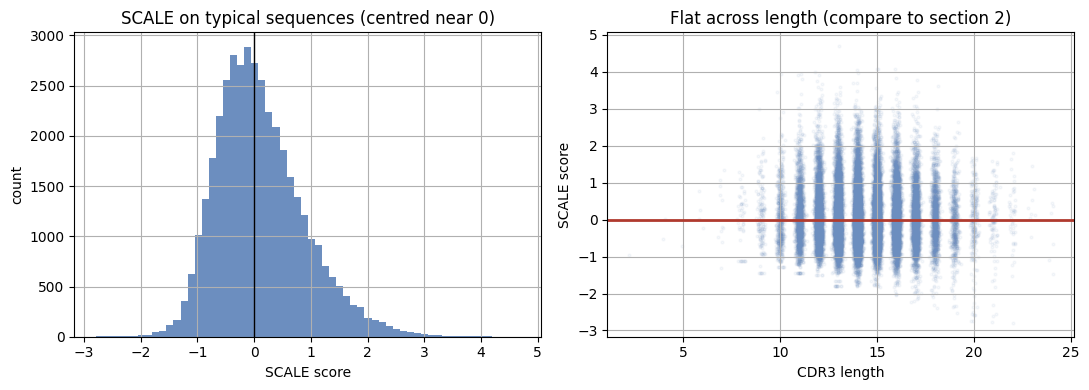

In [5]:
samp4 = rng.choice(len(ref_seqs), size=40_000, replace=False)
samp_seqs = [ref_seqs[i] for i in samp4]
samp_len = ref_len[samp4]
ref_scale = g.scale_score(samp_seqs, calibration)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(ref_scale, bins=60, color="#6c8ebf")
axes[0].axvline(0, color="k", lw=1)
axes[0].set_xlabel("SCALE score"); axes[0].set_ylabel("count")
axes[0].set_title("SCALE on typical sequences (centred near 0)")

axes[1].scatter(samp_len + rng.normal(0, 0.1, samp_len.size), ref_scale,
                s=4, alpha=0.06, color="#6c8ebf")
axes[1].axhline(0, color="#b03a2e", lw=2)
axes[1].set_xlabel("CDR3 length"); axes[1].set_ylabel("SCALE score")
axes[1].set_title("Flat across length (compare to section 2)")
plt.tight_layout(); plt.show()

## 5. Detecting errors

This mirrors the manuscript's noise-detection methodology on a small,
self-contained example. Take a set of clean sequences (sampled from the
foundation's own output) and make matched "error" sets by introducing one
controlled edit per sequence: a substitution, an insertion, or a deletion.
A good anomaly score should give the error sets higher SCALE values, with the
structure-disrupting indels easier to catch than a single substitution.

In [6]:
AAS = "ACDEFGHIKLMNPQRSTVWY"

def substitute(seq, rng):
    i = int(rng.integers(1, len(seq) - 1))
    return seq[:i] + AAS[int(rng.integers(0, 20))] + seq[i + 1:]

def insert(seq, rng):
    i = int(rng.integers(1, len(seq) - 1))
    return seq[:i] + AAS[int(rng.integers(0, 20))] + seq[i:]

def delete(seq, rng):
    i = int(rng.integers(1, len(seq) - 1))
    return seq[:i] + seq[i + 1:]

clean = [s for s in g.simulate(8_000, seed=3).sequences if len(s) >= 7]
error_makers = {"substitution": substitute, "insertion": insert, "deletion": delete}
errored = {name: [fn(s, rng) for s in clean] for name, fn in error_makers.items()}

scale_clean = g.scale_score(clean, calibration)
scale_err = {name: g.scale_score(seqs, calibration) for name, seqs in errored.items()}
print(f"clean median SCALE: {np.median(scale_clean):.2f}")
for name, sc in scale_err.items():
    print(f"  {name:<13s} median SCALE: {np.median(sc):.2f}")

clean median SCALE: -0.00
  substitution  median SCALE: 1.22
  insertion     median SCALE: 1.32
  deletion      median SCALE: 0.87


### A deployment threshold and per-error flag rates

Set the flag threshold at the 98th percentile of clean scores (a 2%
false-positive rate), then measure what fraction of each error type it
catches.

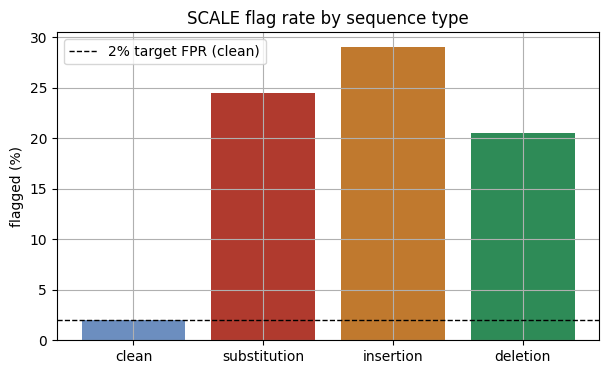

  clean        : 2.0%
  substitution : 24.5%   (12x the clean rate)
  insertion    : 29.0%   (15x the clean rate)
  deletion     : 20.5%   (10x the clean rate)


In [7]:
thr = np.percentile(scale_clean, 98)
rates = {"clean": float(np.mean(scale_clean >= thr))}
rates.update({name: float(np.mean(sc >= thr)) for name, sc in scale_err.items()})

colors = ["#6c8ebf", "#b03a2e", "#c0792e", "#2e8b57"]
plt.bar(list(rates), [100 * v for v in rates.values()], color=colors)
plt.axhline(2, color="k", ls="--", lw=1, label="2% target FPR (clean)")
plt.ylabel("flagged (%)"); plt.title("SCALE flag rate by sequence type")
plt.legend(); plt.show()
base = rates["clean"]
for name, v in rates.items():
    extra = f"   ({v / base:.0f}x the clean rate)" if name != "clean" and base > 0 else ""
    print(f"  {name:<13s}: {v:.1%}{extra}")

### How well does it separate? (ROC / AUC)

Pool clean (label 0) against all errors (label 1). The ROC curve summarises
separability. This AUC is computed live on this toy example; it is **not** a
manuscript result.

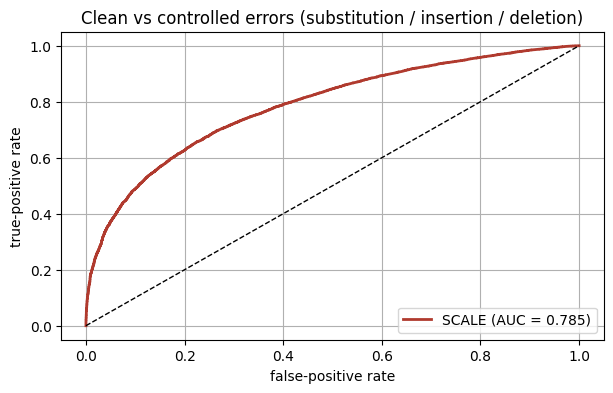

In [8]:
from sklearn.metrics import roc_auc_score, roc_curve

all_err = np.concatenate(list(scale_err.values()))
y = np.r_[np.zeros(len(scale_clean)), np.ones(len(all_err))]
s = np.r_[scale_clean, all_err]
auc = roc_auc_score(y, s)
fpr, tpr, _ = roc_curve(y, s)

plt.plot(fpr, tpr, color="#b03a2e", lw=2, label=f"SCALE (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], "k--", lw=1)
plt.xlabel("false-positive rate"); plt.ylabel("true-positive rate")
plt.title("Clean vs controlled errors (substitution / insertion / deletion)")
plt.legend(loc="lower right"); plt.show()

### Interpreting the result

A **single interior edit is the hardest case**: on a broad foundation that has
seen an enormous variety of sequences, one changed residue often leaves a still
plausible sequence. Even so, at a 2% false-positive rate SCALE enriches errors
roughly an order of magnitude over the clean baseline, and the pooled AUC shows
clear separation. More disruptive corruptions (multiple edits, frameshifts) are
caught far more readily.

In practice you run SCALE across a repertoire, flag the high-scoring tail at a
chosen false-positive rate, and review those sequences as likely errors or
contaminants.

## 6. Reuse the calibration

Calibration simulates from the graph, so build it once and reload the cache
whenever you score new data.

In [9]:
calibration = ScaleCalibration.load("scale_calibration.json")
g.scale_score("CASSLEPSGGTDTQYF", calibration)

-1.0423175620882692

## Summary

- **SCALE** turns `-log Pgen` into a length-invariant anomaly score by
  calibrating against the foundation graph's own simulated output.
- `calibrate_scale()` builds the cache (per-length median/IQR); `scale_score()`
  applies it; `ScaleCalibration.save/load` persists it.
- Flag at a high percentile of clean scores to fix the false-positive rate.

See the [FlashBackGraph API](https://mutejester.github.io/LZGraphs/api/flashback-graph/)
and the [anomaly-detection tutorial](https://mutejester.github.io/LZGraphs/tutorials/flashback-anomaly/)
for more.
